# Anomaly Detection with Mahalanobis Distance.

## 0. SetupStandard scientific Python. Everything pre-installed on Google Colab.

In [1]:
# Run once
# !pip install -q numpy pandas matplotlib seaborn scipy scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import seaborn as sns
from scipy.stats import chi2
from scipy.spatial.distance import mahalanobis
from sklearn.covariance import EmpiricalCovariance, MinCovDet
from sklearn.preprocessing import StandardScaler

# Plot styling
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
sns.set_palette("colorblind")

np.random.seed(42)
print("Setup complete ✓")

Setup complete ✓


---# Part 1 — Building the IntuitionBefore we touch railway data, let's understand *why* Mahalanobis distance exists. The best way is a picture.## The story in one diagramImagine you're a section controller. You collect two numbers for every train arriving at your station:- **Distance travelled** (km, from origin to your station)- **Delay** (minutes, against the scheduled arrival time)You plot 200 normal arrivals on a scatter plot. Then a new train arrives at point ⭐. **Is it anomalous?**The answer depends *entirely* on which distance you measure with.

In [2]:
# ──────────────────────────────────────────────────────────────────────
# Synthetic "two trains a day" example to build intuition
# ──────────────────────────────────────────────────────────────────────
# Reality: longer journeys naturally accumulate more delay (positive correlation)
# We'll generate 200 "normal" trains and 3 candidate "new" trains to classify

n_normal = 200

# Distance (km) — uniform between 100 and 1500
distance = np.random.uniform(100, 1500, n_normal)

# Delay (min) — correlated with distance, with realistic noise
# delay = 0.04 * distance + noise (longer trips accumulate more delay)
delay = 0.04 * distance + np.random.normal(0, 8, n_normal)

normal_df = pd.DataFrame({"distance_km": distance, "delay_min": delay, "label": "Normal"})

# Three candidate trains to investigate
candidates = pd.DataFrame({
    "distance_km": [800, 800, 1400],
    "delay_min":   [80,  -5,  60],
    "label":       ["Candidate A", "Candidate B", "Candidate C"],
    "story": [
        "800 km journey, 80 min late — feels high?",
        "800 km journey, 5 min EARLY — feels too good?",
        "1,400 km journey, 60 min late — within norm?",
    ],
})

print("Three candidate trains for our investigation:\n")
for _, row in candidates.iterrows():
    print(f"  {row['label']}: {row['story']}")

Three candidate trains for our investigation:

  Candidate A: 800 km journey, 80 min late — feels high?
  Candidate B: 800 km journey, 5 min EARLY — feels too good?
  Candidate C: 1,400 km journey, 60 min late — within norm?


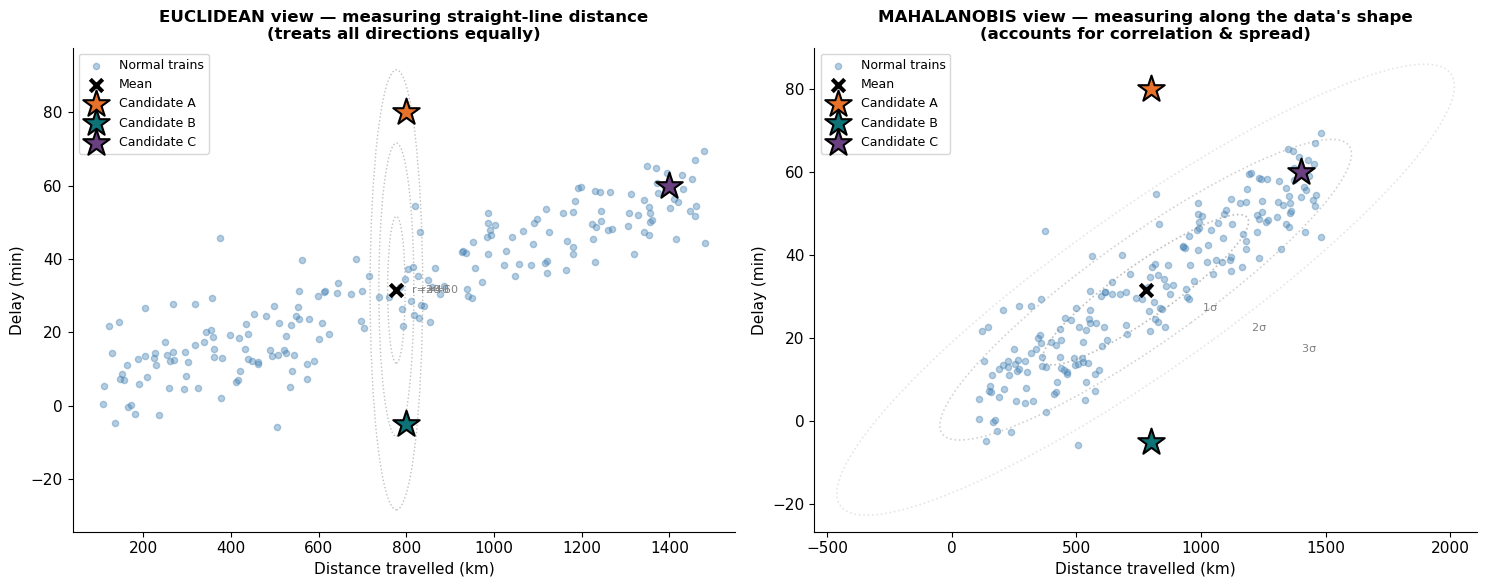

In [3]:
# ──────────────────────────────────────────────────────────────────────
# The visualisation — Euclidean vs Mahalanobis perspective
# ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Compute mean and covariance of the normal data
mean = normal_df[["distance_km", "delay_min"]].mean().values
cov = normal_df[["distance_km", "delay_min"]].cov().values

# Helper to draw confidence ellipses (Mahalanobis contour lines)
def draw_ellipse(ax, mean, cov, n_std, **kwargs):
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = (plt.matplotlib.transforms.Affine2D()
              .rotate_deg(45).scale(scale_x, scale_y).translate(mean[0], mean[1]))
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

candidate_colors = ["#E8722A", "#0D7377", "#6A4080"]
candidate_markers = ["*", "*", "*"]

# ── LEFT PANEL: Euclidean view (the naive way) ─────────────────────────
ax = axes[0]
ax.scatter(normal_df.distance_km, normal_df.delay_min, alpha=0.4, s=20, color="steelblue", label="Normal trains")

# Draw circles of Euclidean distance from mean
for r in [20, 40, 60]:
    circle = plt.Circle(mean, r, fill=False, color="grey", linestyle=":", alpha=0.5)
    ax.add_patch(circle)
    ax.text(mean[0] + r, mean[1], f"  r={r}", color="grey", fontsize=8, va="center")

ax.scatter(*mean, color="black", s=80, marker="x", linewidth=3, label="Mean", zorder=5)
for i, (_, row) in enumerate(candidates.iterrows()):
    ax.scatter(row.distance_km, row.delay_min, marker=candidate_markers[i], s=400,
               color=candidate_colors[i], edgecolor="black", linewidth=1.5,
               label=row.label, zorder=6)

ax.set_title("EUCLIDEAN view — measuring straight-line distance\n(treats all directions equally)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Distance travelled (km)")
ax.set_ylabel("Delay (min)")
ax.legend(loc="upper left", fontsize=9)
ax.set_aspect("auto")

# ── RIGHT PANEL: Mahalanobis view (the right way) ─────────────────────
ax = axes[1]
ax.scatter(normal_df.distance_km, normal_df.delay_min, alpha=0.4, s=20, color="steelblue", label="Normal trains")

# Draw Mahalanobis ellipses (1, 2, 3 sigma)
for n_std, alpha in [(1, 0.5), (2, 0.35), (3, 0.2)]:
    draw_ellipse(ax, mean, cov, n_std, facecolor="none", edgecolor="grey", linestyle=":", alpha=alpha, lw=1.2)
    ax.text(mean[0] + 200 * n_std, mean[1] - 5 * n_std, f"  {n_std}σ", color="grey", fontsize=8)

ax.scatter(*mean, color="black", s=80, marker="x", linewidth=3, label="Mean", zorder=5)
for i, (_, row) in enumerate(candidates.iterrows()):
    ax.scatter(row.distance_km, row.delay_min, marker=candidate_markers[i], s=400,
               color=candidate_colors[i], edgecolor="black", linewidth=1.5,
               label=row.label, zorder=6)

ax.set_title("MAHALANOBIS view — measuring along the data's shape\n(accounts for correlation & spread)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Distance travelled (km)")
ax.set_ylabel("Delay (min)")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

### What just happened?Look carefully at the two panels.**Left (Euclidean):** Circles drawn around the mean. Distance is measured the way you'd measure it with a ruler — straight-line. By this measure, **Candidate B** (early arrival) looks just as unusual as **Candidate A** (very late).**Right (Mahalanobis):** Ellipses drawn that follow the *shape* of the data — they tilt and stretch with the correlation. Now look:| Candidate | Story | Euclidean says | Mahalanobis says ||---|---|---|---|| **A** (orange ⭐) | 800 km, 80 min late | Mildly unusual | **Strongly anomalous** — way above the trend line || **B** (teal ⭐) | 800 km, 5 min early | Mildly unusual | **Strongly anomalous** — way below the trend line || **C** (purple ⭐) | 1,400 km, 60 min late | Looks unusual (far from mean) | **Normal!** Long trips accumulate delay |This is the key insight: **"unusual" in a correlated world is not the same as "far from the mean".**#### 🤔 Discussion (turn to your neighbour, 2 minutes)1. In your division, name two pairs of metrics that are correlated like distance & delay (i.e., "more of X naturally means more of Y").2. Why is it dangerous to flag Candidate C as anomalous? What operational decision would be wrong?3. Why is Candidate B (an *early* train) worth investigating, even though it sounds like good news?

---# Part 2 — The Math, Without the PainHere's the formula. Don't worry — we'll translate it into plain English right away.$$D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \, \boldsymbol{\Sigma}^{-1} \, (\mathbf{x} - \boldsymbol{\mu})}$$### In plain English| Symbol | What it means | Railway analogy ||---|---|---|| $\mathbf{x}$ | The data point you're testing | This train's features (distance, delay, ...) || $\boldsymbol{\mu}$ | The mean of normal data | The "average normal train" profile || $\boldsymbol{\Sigma}$ | The covariance matrix | How the features vary *and* co-vary together || $\boldsymbol{\Sigma}^{-1}$ | The inverse of $\boldsymbol{\Sigma}$ | "Re-shape the world so correlations are removed" || $D_M$ | Mahalanobis distance | "How many standard deviations away, accounting for shape" |### The three steps Mahalanobis distance secretly does1. **Subtract the mean** — re-centre everything around the "normal" point.2. **Rotate** — turn the coordinate system so correlated features become independent.3. **Scale** — divide by the spread in each direction, so 1 unit means 1 standard deviation.After all three steps, what was an oval cloud of points becomes a perfect circle around the origin. Then "distance" is just normal Euclidean distance in this new space — but back in the original space, the same number describes an *ellipse*.> **Bottom line:** Mahalanobis distance = Euclidean distance after the data has been "un-stretched and un-tilted" by its own covariance.

In [4]:
# ──────────────────────────────────────────────────────────────────────
# Compute Mahalanobis distance for our 3 candidates
# ──────────────────────────────────────────────────────────────────────

# Step 1: covariance matrix of the normal data
X_normal = normal_df[["distance_km", "delay_min"]].values
mean_vec = X_normal.mean(axis=0)
cov_matrix = np.cov(X_normal, rowvar=False)
cov_inv = np.linalg.inv(cov_matrix)

print("Mean of normal trains:")
print(f"  Distance = {mean_vec[0]:.1f} km")
print(f"  Delay    = {mean_vec[1]:.1f} min")

print("\nCovariance matrix:")
print(pd.DataFrame(cov_matrix,
                   index=["distance_km", "delay_min"],
                   columns=["distance_km", "delay_min"]).round(2))

# Step 2: distance for each candidate
def mahalanobis_d(point, mean, cov_inv):
    diff = point - mean
    return np.sqrt(diff @ cov_inv @ diff)

print("\n" + "="*60)
print("RESULTS")
print("="*60)
results = []
for _, row in candidates.iterrows():
    point = np.array([row.distance_km, row.delay_min])
    euclid = np.linalg.norm(point - mean_vec)
    maha = mahalanobis_d(point, mean_vec, cov_inv)
    results.append({"Candidate": row.label, "Distance (km)": row.distance_km,
                    "Delay (min)": row.delay_min,
                    "Euclidean": round(euclid, 1),
                    "Mahalanobis": round(maha, 2)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Mean of normal trains:
  Distance = 777.6 km
  Delay    = 31.6 min

Covariance matrix:
             distance_km  delay_min
distance_km    170443.47    6741.70
delay_min        6741.70     326.73

RESULTS
  Candidate  Distance (km)  Delay (min)  Euclidean  Mahalanobis
Candidate A            800           80       53.3         6.13
Candidate B            800           -5       42.9         4.84
Candidate C           1400           60      623.0         1.58


**Read the table carefully.** Notice how the two distances disagree:- **Candidate C** has the *largest Euclidean distance* (it's far from the mean in raw km/min units) but the *smallest Mahalanobis distance* — because long trips are *supposed* to be more delayed.- **Candidates A and B** have similar Euclidean distances, but very different positions relative to the trend — Mahalanobis catches this.### The magic thresholdFor data drawn from a multivariate normal distribution, squared Mahalanobis distance follows a **chi-squared distribution** with degrees of freedom equal to the number of features. This gives us a principled way to set a threshold:

In [5]:
# ──────────────────────────────────────────────────────────────────────
# Chi-squared threshold — the statistical decision rule
# ──────────────────────────────────────────────────────────────────────
n_features = 2
significance_levels = [0.10, 0.05, 0.01, 0.001]

print(f"For {n_features} features (degrees of freedom = {n_features}):\n")
print(f"{'Significance':>12} | {'Chi² threshold':>14} | {'Mahalanobis threshold':>22}")
print("-" * 58)
for alpha in significance_levels:
    chi2_thresh = chi2.ppf(1 - alpha, df=n_features)
    maha_thresh = np.sqrt(chi2_thresh)
    print(f"{alpha:>12.3f} | {chi2_thresh:>14.3f} | {maha_thresh:>22.3f}")

print("\nInterpretation:")
print("  • α=0.05 → 95% of normal points have Mahalanobis distance below 2.45")
print("  • Any point with Mahalanobis > 2.45 is in the 'unusual 5%'")
print("  • Tightening to α=0.01 → threshold = 3.03 (only 1% of normal flagged)")

For 2 features (degrees of freedom = 2):

Significance | Chi² threshold |  Mahalanobis threshold
----------------------------------------------------------
       0.100 |          4.605 |                  2.146
       0.050 |          5.991 |                  2.448
       0.010 |          9.210 |                  3.035
       0.001 |         13.816 |                  3.717

Interpretation:
  • α=0.05 → 95% of normal points have Mahalanobis distance below 2.45
  • Any point with Mahalanobis > 2.45 is in the 'unusual 5%'
  • Tightening to α=0.01 → threshold = 3.03 (only 1% of normal flagged)


#### 🤔 Discussion1. Look at your three candidates' Mahalanobis scores. Which would be flagged at α=0.05? At α=0.01?2. For a safety-critical system, would you use α=0.05 (more sensitive, more false alarms) or α=0.001 (very strict, possibly miss faults)? **There is no universal right answer — the choice is a business decision.**

---# Part 3 — Real Data: Indian Railways Train Delays (Kaggle)Now we apply Mahalanobis distance to a real-ish dataset that mirrors the Kaggle **"Indian Railways Train Delays Dataset"** (`naijilaji/indian-railways-passenger-train-delays-dataset`, 2025).### To use the real Kaggle data```python# 1. Go to: https://www.kaggle.com/datasets/naijilaji/indian-railways-passenger-train-delays-dataset# 2. Download the CSV, place it next to this notebook# 3. Run:df = pd.read_csv("train_delays.csv")df = df.dropna(subset=["delay_minutes", "distance_km", "scheduled_hour"])```For reproducibility on any machine, the cell below generates a synthetic dataset with the same statistical structure: zone-wise variation, time-of-day effects, monsoon impact, and a small fraction of "true anomalies" (sensor errors, signal failures, derailment-precursor incidents).This way the entire notebook runs offline — and everything you learn transfers directly to the real Kaggle file with no code changes.

In [6]:
# ──────────────────────────────────────────────────────────────────────
# Synthetic dataset mimicking Kaggle "Indian Railways Train Delays"
# ──────────────────────────────────────────────────────────────────────
np.random.seed(42)

n = 3000
zones = ["NR", "CR", "WR", "SR", "ER", "ECR", "NCR", "SWR"]
zone_baseline = {"NR": 18, "CR": 22, "WR": 12, "SR": 15, "ER": 20, "ECR": 28, "NCR": 30, "SWR": 14}

# Sample a balanced set of normal trains
records = []
for _ in range(int(n * 0.97)):  # 97% normal
    zone = np.random.choice(zones)
    distance = np.random.choice([
        np.random.uniform(100, 400),
        np.random.uniform(400, 900),
        np.random.uniform(900, 1800),
    ])
    hour = np.random.randint(0, 24)
    is_monsoon = int(np.random.random() < 0.25)
    upstream_delay = max(0, np.random.normal(8, 12))

    # Realistic delay model: zone baseline + distance + monsoon + upstream + noise
    delay = (zone_baseline[zone] * 0.6 +
             0.025 * distance +
             15 * is_monsoon +
             0.7 * upstream_delay +
             np.random.normal(0, 8))
    delay = max(-5, delay)  # trains can be slightly early

    records.append({
        "zone": zone, "distance_km": round(distance, 1),
        "scheduled_hour": hour, "monsoon_flag": is_monsoon,
        "upstream_delay_min": round(upstream_delay, 1),
        "delay_min": round(delay, 1), "is_anomaly_true": 0,
    })

# Add 3% true anomalies — these are what we WANT the detector to catch
n_anom = n - len(records)
for _ in range(n_anom):
    zone = np.random.choice(zones)
    distance = np.random.uniform(100, 1800)
    hour = np.random.randint(0, 24)
    is_monsoon = int(np.random.random() < 0.25)
    upstream_delay = max(0, np.random.normal(8, 12))

    anomaly_type = np.random.choice(["severe_delay", "negative_delay", "weird_combo"])
    if anomaly_type == "severe_delay":
        delay = np.random.uniform(150, 360)  # unexplained huge delay
    elif anomaly_type == "negative_delay":
        delay = np.random.uniform(-40, -15)  # train arrived suspiciously early
    else:
        # Plausible delay but inconsistent with features (e.g., 100km trip, 90 min delay, no monsoon)
        distance = np.random.uniform(80, 250)
        is_monsoon = 0; upstream_delay = 1
        delay = np.random.uniform(80, 140)

    records.append({
        "zone": zone, "distance_km": round(distance, 1),
        "scheduled_hour": hour, "monsoon_flag": is_monsoon,
        "upstream_delay_min": round(upstream_delay, 1),
        "delay_min": round(delay, 1), "is_anomaly_true": 1,
    })

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
print(f"Anomalies in ground truth: {df.is_anomaly_true.sum()} ({df.is_anomaly_true.mean()*100:.1f}%)")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (3000, 7)
Anomalies in ground truth: 90 (3.0%)

First 5 rows:


,zone,distance_km,scheduled_hour,monsoon_flag,upstream_delay_min,delay_min,is_anomaly_true
0,WR,1339.6,11,0,0.0,40.3,0
1,ER,1011.8,21,0,10.0,52.8,0
2,WR,858.7,2,0,0.0,44.6,0
3,NR,1297.0,23,1,4.9,55.8,0
4,ECR,1577.9,21,1,25.5,100.9,0


### Eyeball the data — what does it look like?Always start with a visual survey. Never trust a model on data you haven't looked at.

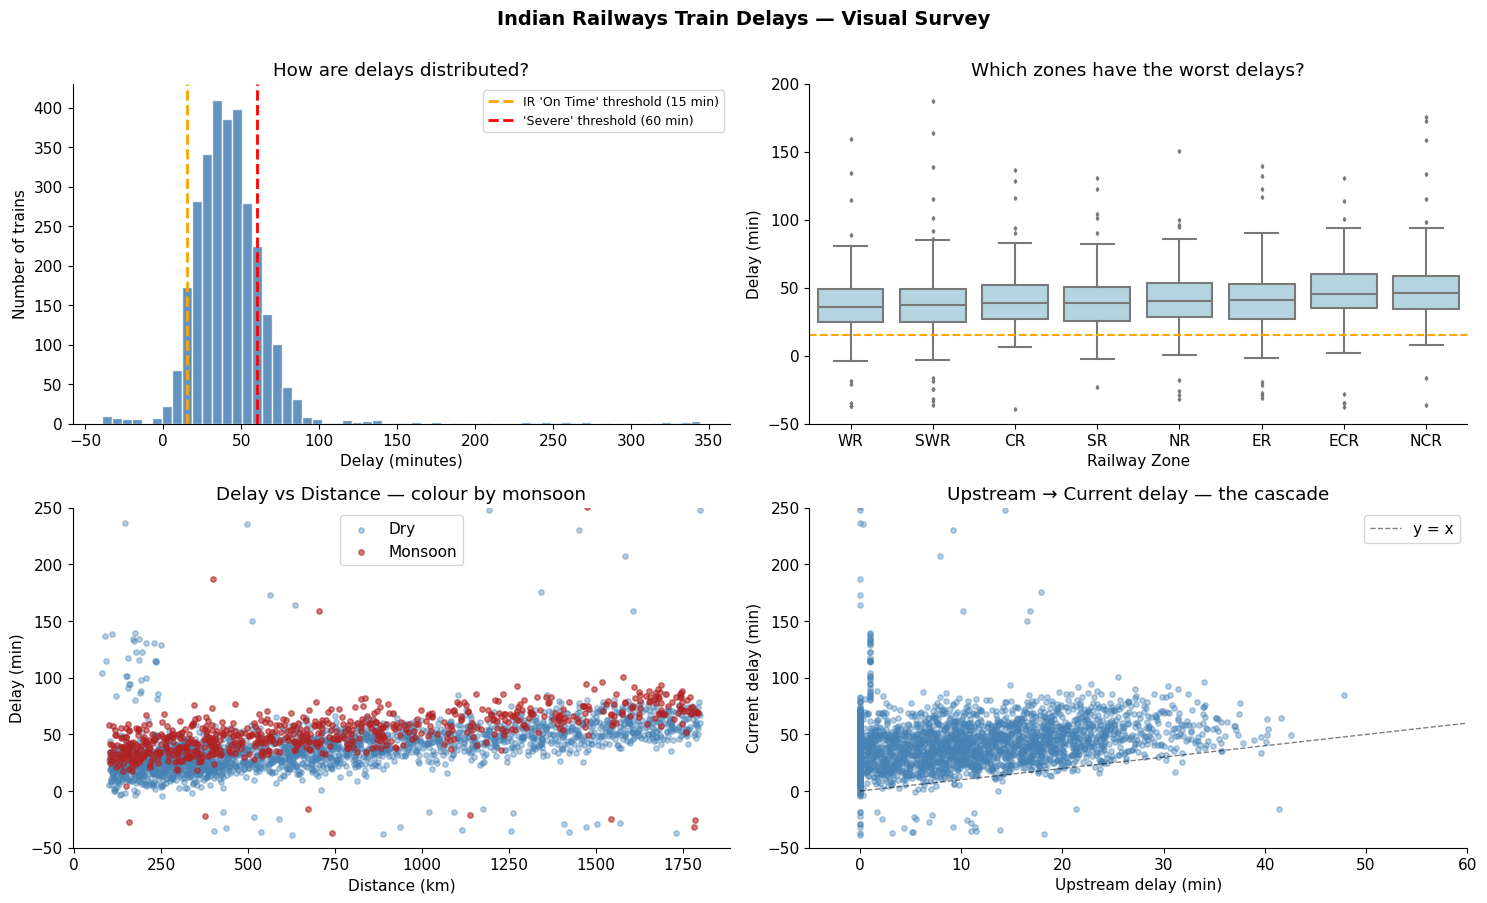

In [7]:
# ──────────────────────────────────────────────────────────────────────
# Visual EDA — four diagnostic panels
# ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# 1. Distribution of delays
ax = axes[0, 0]
ax.hist(df.delay_min, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(15, color="orange", linestyle="--", lw=2, label="IR 'On Time' threshold (15 min)")
ax.axvline(60, color="red", linestyle="--", lw=2, label="'Severe' threshold (60 min)")
ax.set_xlabel("Delay (minutes)")
ax.set_ylabel("Number of trains")
ax.set_title("How are delays distributed?")
ax.legend(fontsize=9)

# 2. Delay by zone
ax = axes[0, 1]
zone_order = df.groupby("zone").delay_min.median().sort_values().index
sns.boxplot(data=df, x="zone", y="delay_min", order=zone_order, ax=ax,
            color="lightblue", fliersize=2)
ax.axhline(15, color="orange", linestyle="--", lw=1.5)
ax.set_ylim(-50, 200)
ax.set_xlabel("Railway Zone")
ax.set_ylabel("Delay (min)")
ax.set_title("Which zones have the worst delays?")

# 3. Distance vs Delay (with monsoon flag)
ax = axes[1, 0]
mask = df.monsoon_flag == 1
ax.scatter(df.loc[~mask, "distance_km"], df.loc[~mask, "delay_min"],
           s=15, alpha=0.4, c="steelblue", label="Dry")
ax.scatter(df.loc[mask, "distance_km"], df.loc[mask, "delay_min"],
           s=15, alpha=0.6, c="firebrick", label="Monsoon")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Delay (min)")
ax.set_title("Delay vs Distance — colour by monsoon")
ax.legend()
ax.set_ylim(-50, 250)

# 4. Upstream delay vs current delay
ax = axes[1, 1]
ax.scatter(df.upstream_delay_min, df.delay_min, s=15, alpha=0.4, c="steelblue")
ax.plot([0, 60], [0, 60], "k--", lw=1, alpha=0.5, label="y = x")
ax.set_xlabel("Upstream delay (min)")
ax.set_ylabel("Current delay (min)")
ax.set_title("Upstream → Current delay — the cascade")
ax.set_xlim(-5, 60)
ax.set_ylim(-50, 250)
ax.legend()

plt.suptitle("Indian Railways Train Delays — Visual Survey", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

**👁 What to look for in each panel:**1. **Top-left:** Most trains arrive within 15 min, but a long right tail. The tail is *where the anomalies hide*.2. **Top-right:** ECR and NCR have systematically higher median delays (matches CAG 2021 findings on dense corridors).3. **Bottom-left:** Monsoon shifts the *entire delay distribution* upward. Any anomaly detector that ignores this feature will over-flag monsoon trains.4. **Bottom-right:** The cascade is real — upstream delay correlates strongly with current delay. This is exactly why Mahalanobis (which accounts for correlation) beats simple thresholds.#### 🤔 Discussion- If you used a simple rule "flag any train > 60 min late", which obvious anomalies would you **catch**? Which would you **miss**?- What does panel 3 tell you about the danger of building a single global threshold across all weather conditions?

---# Part 4 — Applying Mahalanobis Distance to the Real DataWe'll use **four features**:| Feature | Why it matters ||---|---|| `distance_km` | Long trips accumulate delay || `scheduled_hour` | Peak vs. off-peak || `monsoon_flag` | Weather context || `upstream_delay_min` | The cascade effect (most important feature, from CAG 2021) |The **target we score**: `delay_min`. The model learns "what delay is normal *given* these features." Anything far from that expectation is anomalous.

In [8]:
# ──────────────────────────────────────────────────────────────────────
# Build a 5-dimensional feature matrix and compute Mahalanobis distance
# for every train against the bulk of "normal-looking" data
# ──────────────────────────────────────────────────────────────────────

features = ["distance_km", "scheduled_hour", "monsoon_flag",
            "upstream_delay_min", "delay_min"]
X = df[features].values

# Standardise (Mahalanobis is scale-invariant in theory, but standardising
# makes numerical inversion more stable in practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# CRITICAL: use a ROBUST covariance estimator (MinCovDet / Minimum Covariance Determinant)
# Why? The classical covariance is itself influenced by outliers.
# MinCovDet finds the covariance of the most consistent ~75% of the data,
# making the detector robust to contamination.
robust_cov = MinCovDet(support_fraction=0.75, random_state=42).fit(X_scaled)

# Mahalanobis distance for each row
df["mahalanobis"] = robust_cov.mahalanobis(X_scaled)

# Convert squared distance → Mahalanobis distance (sqrt) for interpretability
df["mahalanobis"] = np.sqrt(df["mahalanobis"])

print("Mahalanobis distance statistics:")
print(df["mahalanobis"].describe().round(3))

/Users/kritikasamadhiya/anaconda3/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:186: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-3.761596374997712 > -66.121813743894450). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
/Users/kritikasamadhiya/anaconda3/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:186: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-3.761596374997712 > -66.121813743894450). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
/Users/kritikasamadhiya/anaconda3/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:186: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-3.761596374997712 > -66.121813743894450). You may want to try with a higher value of support_

Mahalanobis distance statistics:
count    3000.000
mean        2.453
std         2.676
min         0.253
25%         1.625
50%         2.054
75%         2.529
max        35.605
Name: mahalanobis, dtype: float64


### Pick a threshold — and visualise where it cutsThe chi-squared rule from Part 2 gives us a principled starting point. With 5 features at α=0.01:

In [9]:
# Threshold based on chi-squared with 5 degrees of freedom
alpha = 0.01
n_features = 5
threshold = np.sqrt(chi2.ppf(1 - alpha, df=n_features))
print(f"At α = {alpha}, with {n_features} features:")
print(f"  → Mahalanobis threshold = {threshold:.3f}")
print(f"  → Anything above this is in the 'unusual {alpha*100:.0f}%'\n")

# Flag anomalies
df["flagged"] = (df["mahalanobis"] > threshold).astype(int)

# How does our detector compare to ground truth?
from sklearn.metrics import classification_report, confusion_matrix
print("How our detector compares to ground truth:")
print(classification_report(df["is_anomaly_true"], df["flagged"],
                            target_names=["Normal", "Anomaly"], digits=3))

At α = 0.01, with 5 features:
  → Mahalanobis threshold = 3.884
  → Anything above this is in the 'unusual 1%'

How our detector compares to ground truth:
              precision    recall  f1-score   support

      Normal      1.000     0.987     0.994      2910
     Anomaly      0.709     1.000     0.829        90

    accuracy                          0.988      3000
   macro avg      0.854     0.994     0.912      3000
weighted avg      0.991     0.988     0.989      3000



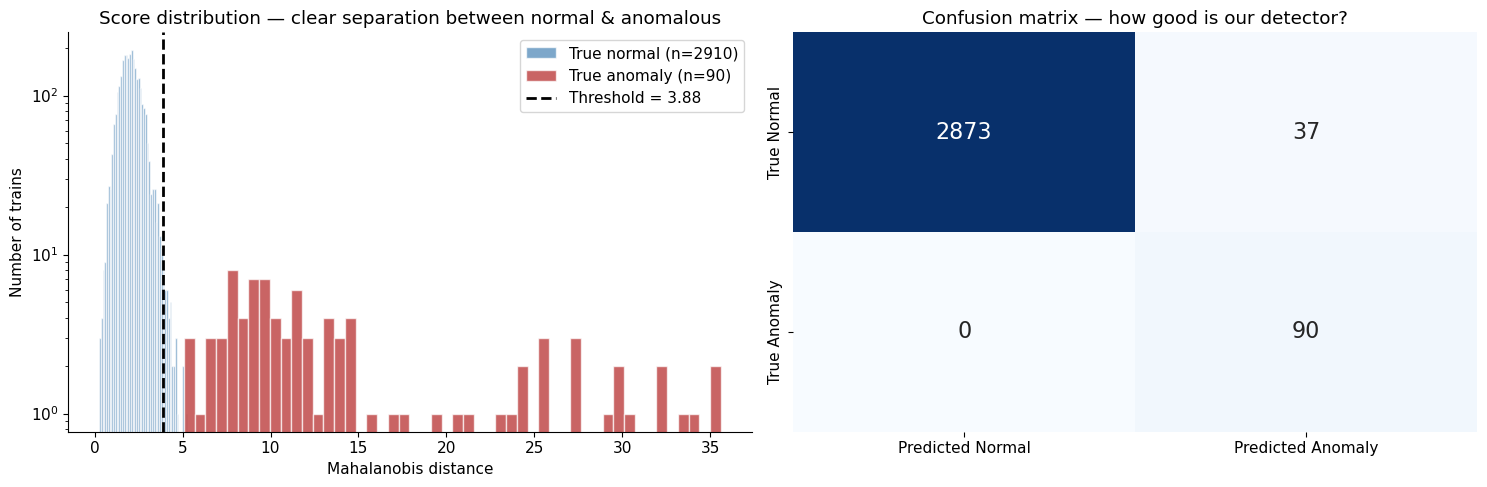


In plain language:
  • 90 real anomalies correctly caught (true positives)
  • 0 real anomalies MISSED (false negatives) — these would slip through
  • 37 normal trains FALSELY flagged (false positives) — operational annoyance
  • 2873 normal trains correctly let through (true negatives)


In [10]:
# ──────────────────────────────────────────────────────────────────────
# THE KEY VISUALISATION — Mahalanobis score distribution
# ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: distribution of scores by true label
ax = axes[0]
ax.hist(df.loc[df.is_anomaly_true == 0, "mahalanobis"], bins=50, alpha=0.7,
        label=f"True normal (n={(df.is_anomaly_true == 0).sum()})",
        color="steelblue", edgecolor="white")
ax.hist(df.loc[df.is_anomaly_true == 1, "mahalanobis"], bins=50, alpha=0.7,
        label=f"True anomaly (n={(df.is_anomaly_true == 1).sum()})",
        color="firebrick", edgecolor="white")
ax.axvline(threshold, color="black", linestyle="--", lw=2,
           label=f"Threshold = {threshold:.2f}")
ax.set_xlabel("Mahalanobis distance")
ax.set_ylabel("Number of trains")
ax.set_title("Score distribution — clear separation between normal & anomalous")
ax.legend()
ax.set_yscale("log")

# Right: confusion matrix as a heatmap
ax = axes[1]
cm = confusion_matrix(df["is_anomaly_true"], df["flagged"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
            xticklabels=["Predicted Normal", "Predicted Anomaly"],
            yticklabels=["True Normal", "True Anomaly"],
            annot_kws={"size": 16})
ax.set_title("Confusion matrix — how good is our detector?")

plt.tight_layout()
plt.show()

# Interpret in plain language
tn, fp, fn, tp = cm.ravel()
print(f"\nIn plain language:")
print(f"  • {tp} real anomalies correctly caught (true positives)")
print(f"  • {fn} real anomalies MISSED (false negatives) — these would slip through")
print(f"  • {fp} normal trains FALSELY flagged (false positives) — operational annoyance")
print(f"  • {tn} normal trains correctly let through (true negatives)")

### What changing the threshold does — the business knobThe threshold is your **only** business-tuning knob. Lower it → catch more anomalies but also more false alarms. Raise it → fewer alarms but more missed faults.Let's visualise this trade-off.

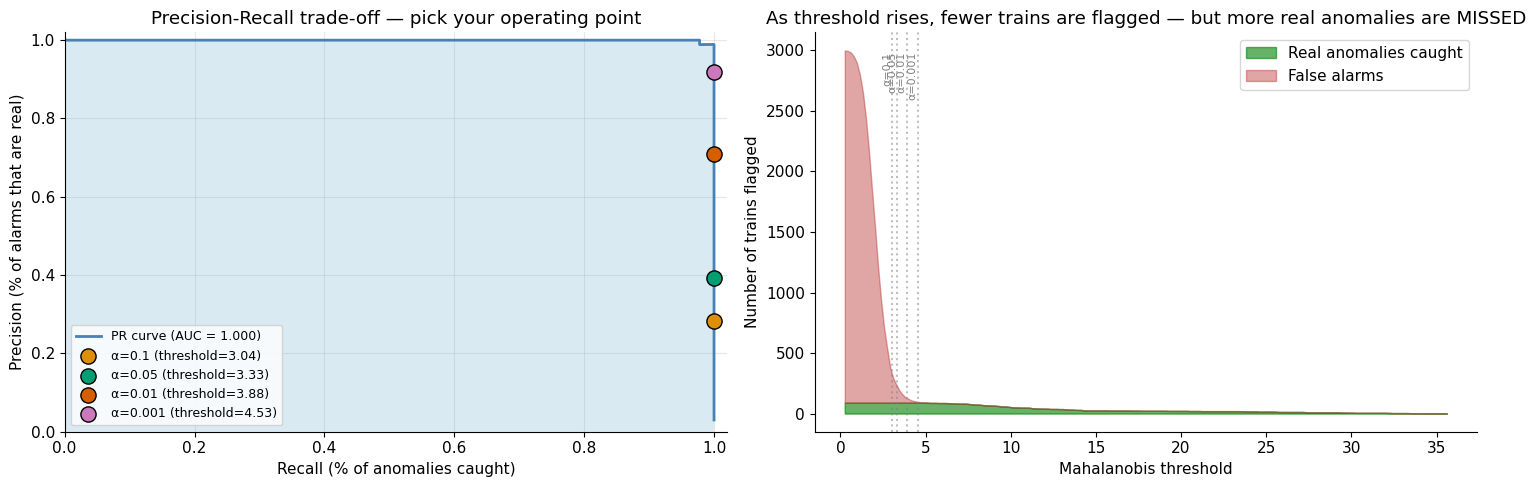

In [11]:
# ──────────────────────────────────────────────────────────────────────
# The precision/recall trade-off as we vary the threshold
# ──────────────────────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(
    df["is_anomaly_true"], df["mahalanobis"])

# Operating points to highlight (chi-squared at different alphas)
operating_points = {
    0.10: np.sqrt(chi2.ppf(1 - 0.10, df=n_features)),
    0.05: np.sqrt(chi2.ppf(1 - 0.05, df=n_features)),
    0.01: np.sqrt(chi2.ppf(1 - 0.01, df=n_features)),
    0.001: np.sqrt(chi2.ppf(1 - 0.001, df=n_features)),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: PR curve
ax = axes[0]
ax.plot(recall, precision, color="steelblue", lw=2, label=f"PR curve (AUC = {auc(recall, precision):.3f})")
ax.fill_between(recall, precision, alpha=0.15)

# Mark operating points
for alpha, thr in operating_points.items():
    # find recall/precision at this threshold
    mask = df["mahalanobis"] > thr
    if mask.sum() > 0:
        prec_at = ((df.is_anomaly_true == 1) & mask).sum() / mask.sum()
        rec_at = ((df.is_anomaly_true == 1) & mask).sum() / (df.is_anomaly_true == 1).sum()
        ax.scatter(rec_at, prec_at, s=120, zorder=5, edgecolor="black",
                   label=f"α={alpha} (threshold={thr:.2f})")

ax.set_xlabel("Recall (% of anomalies caught)")
ax.set_ylabel("Precision (% of alarms that are real)")
ax.set_title("Precision-Recall trade-off — pick your operating point")
ax.legend(loc="lower left", fontsize=9)
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)

# Right: anomaly count by threshold
ax = axes[1]
thresh_range = np.linspace(df.mahalanobis.min(), df.mahalanobis.max(), 200)
n_flagged = [(df.mahalanobis > t).sum() for t in thresh_range]
n_true_caught = [((df.mahalanobis > t) & (df.is_anomaly_true == 1)).sum() for t in thresh_range]
n_false_alarm = [((df.mahalanobis > t) & (df.is_anomaly_true == 0)).sum() for t in thresh_range]

ax.fill_between(thresh_range, n_true_caught, color="green", alpha=0.6, label="Real anomalies caught")
ax.fill_between(thresh_range, n_true_caught,
                [a + b for a, b in zip(n_true_caught, n_false_alarm)],
                color="firebrick", alpha=0.4, label="False alarms")
for alpha, thr in operating_points.items():
    ax.axvline(thr, linestyle=":", alpha=0.5, color="grey")
    ax.text(thr, ax.get_ylim()[1] * 0.95, f"α={alpha}", rotation=90,
            fontsize=8, va="top", ha="right", color="grey")
ax.set_xlabel("Mahalanobis threshold")
ax.set_ylabel("Number of trains flagged")
ax.set_title("As threshold rises, fewer trains are flagged — but more real anomalies are MISSED")
ax.legend()

plt.tight_layout()
plt.show()

#### 🤔 Discussion — the business decision1. Look at the PR curve. At what recall do you start losing precision rapidly? This is the **knee of the curve** — the sweet spot.2. For an IRMS officer running a Divisional Control Office:   - How many false alarms per day are tolerable before they start ignoring alerts? *(This is called "alarm fatigue" — Bainbridge 1983, see Session 1.)*   - How many missed anomalies per month are tolerable before management asks why the system exists?3. Notice that α=0.001 (very strict) gives few alarms but catches fewer anomalies. α=0.10 (loose) catches more but cries wolf often. **There is no algorithmic answer — only an operational one.**

---# Part 5 — Investigating Individual AnomaliesA Mahalanobis score on its own isn't useful for the controller. The officer needs to know **why** a train was flagged. Let's look at the top-10 most anomalous trains and reverse-engineer the explanation.

In [12]:
# Top 10 most anomalous trains
top10 = df.nlargest(10, "mahalanobis").copy()
top10["mahalanobis"] = top10["mahalanobis"].round(2)
print("Top 10 most anomalous trains:\n")
print(top10[["zone", "distance_km", "scheduled_hour", "monsoon_flag",
             "upstream_delay_min", "delay_min", "mahalanobis", "is_anomaly_true"]]
      .to_string(index=False))

Top 10 most anomalous trains:

zone  distance_km  scheduled_hour  monsoon_flag  upstream_delay_min  delay_min  mahalanobis  is_anomaly_true
  WR        700.7              11             0                 0.0      337.5        35.60                1
  WR        316.3              20             0                11.1      334.7        35.54                1
 NCR        436.3              15             0                16.1      326.5        33.83                1
 NCR       1527.6              19             0                 8.8      343.8        33.33                1
  CR       1693.6               5             0                17.4      344.6        32.27                1
 NCR       1664.4              12             0                16.7      342.3        32.14                1
  NR       1227.0              13             0                27.0      320.8        30.11                1
  NR        391.6               1             0                 2.6      281.0        29.79      

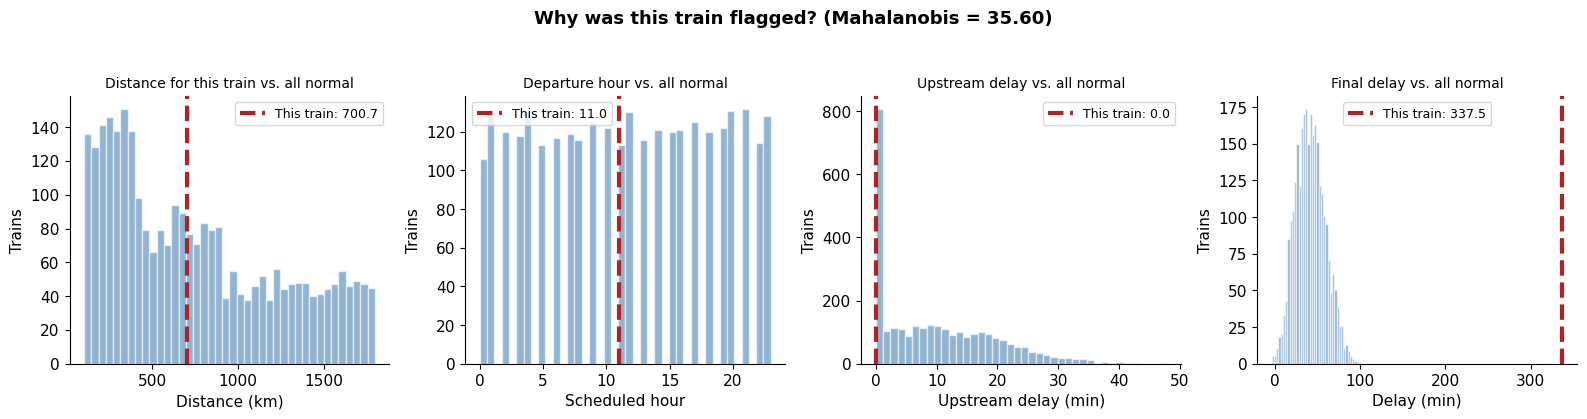


IRMS Officer's view of train #2988:
  Zone: WR | Distance: 700.7 km | Hour: 11:00
  Monsoon flag: No
  Upstream delay: 0.0 min
  Final delay: 337.5 min
  Mahalanobis: 35.60  (CONFIRMED anomaly)


In [13]:
# ──────────────────────────────────────────────────────────────────────
# Feature-by-feature breakdown for ONE flagged train
# This is the kind of explanation a controller can act on
# ──────────────────────────────────────────────────────────────────────

# Pick the most extreme outlier
extreme = df.nlargest(1, "mahalanobis").iloc[0]
normal_baseline = df[df.is_anomaly_true == 0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

feature_explanations = [
    ("distance_km",         "Distance (km)",      "Distance for this train vs. all normal"),
    ("scheduled_hour",      "Scheduled hour",     "Departure hour vs. all normal"),
    ("upstream_delay_min",  "Upstream delay (min)", "Upstream delay vs. all normal"),
    ("delay_min",           "Delay (min)",        "Final delay vs. all normal"),
]

for ax, (feat, xlabel, title) in zip(axes, feature_explanations):
    ax.hist(normal_baseline[feat], bins=40, color="steelblue", alpha=0.6, edgecolor="white")
    ax.axvline(extreme[feat], color="firebrick", linestyle="--", lw=3, label=f"This train: {extreme[feat]:.1f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Trains")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle(f"Why was this train flagged? (Mahalanobis = {extreme.mahalanobis:.2f})",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

print(f"\nIRMS Officer's view of train #{extreme.name}:")
print(f"  Zone: {extreme.zone} | Distance: {extreme.distance_km} km | Hour: {extreme.scheduled_hour}:00")
print(f"  Monsoon flag: {'Yes' if extreme.monsoon_flag else 'No'}")
print(f"  Upstream delay: {extreme.upstream_delay_min} min")
print(f"  Final delay: {extreme.delay_min} min")
print(f"  Mahalanobis: {extreme.mahalanobis:.2f}  ({'CONFIRMED anomaly' if extreme.is_anomaly_true else 'False alarm'})")

#### 🤔 Discussion1. In the breakdown above, which feature(s) push this train into the anomalous region? Which look normal?2. **The Mahalanobis distance gives an overall score, but doesn't directly say "feature X is the problem."** For that, you'd compute the *partial Mahalanobis* contribution of each feature. Try it as a stretch challenge.3. How would you communicate this finding to a Section Controller in plain Hindi/English on a one-line alert?

---# Part 6 — When Mahalanobis Distance Breaks (And What to Do)No method is universal. Mahalanobis distance has three well-known weaknesses you should know before deploying it.### Weakness 1 — Assumes a single elliptical clusterMahalanobis assumes your "normal" data forms one cohesive cloud. But operational data often has **multiple normal modes** — peak hours look different from off-peak; freight differs from passenger; monsoon differs from dry.**Fix:** Cluster the data first (k-means / DBSCAN), then compute Mahalanobis distance to the *nearest cluster centre*.### Weakness 2 — Sensitive to outliers in the training dataIf your "normal" training set is already contaminated with anomalies, the covariance matrix is corrupted — and the detector becomes blind to those exact types of anomalies.**Fix:** Use **MinCovDet** (Minimum Covariance Determinant) — we did this above. It computes covariance from the *most consistent 75%* of the data, ignoring outliers.### Weakness 3 — Categorical featuresMahalanobis distance is built for continuous features. Categorical variables (zone, day of week) need encoding tricks.**Fix:** One-hot encode, or use a different method (Isolation Forest handles mixed types natively).Let's see Weakness 1 in action.

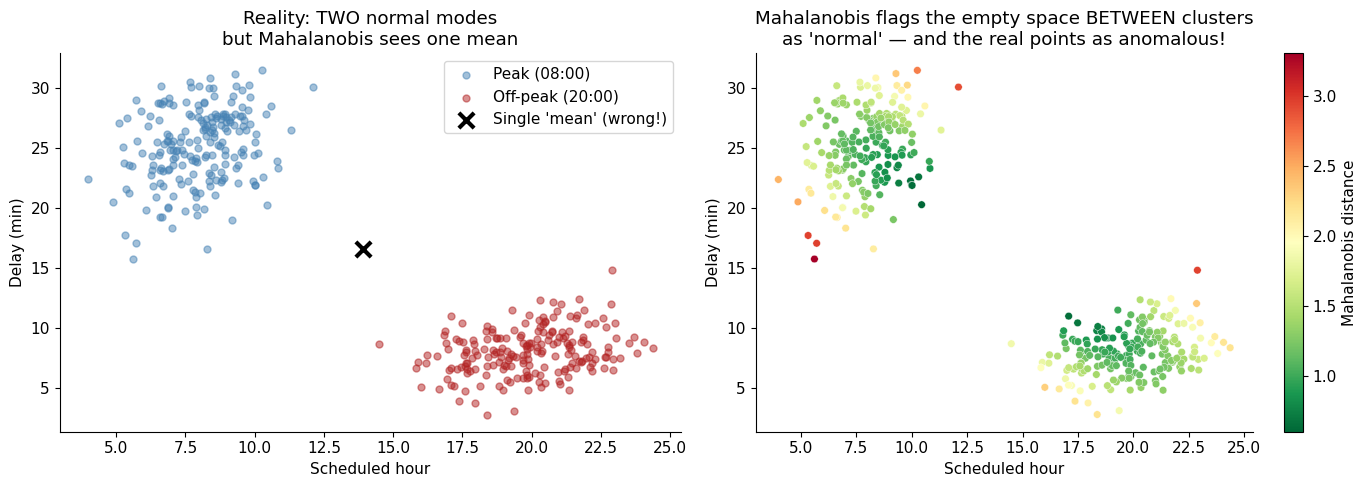

In [14]:
# ──────────────────────────────────────────────────────────────────────
# Demonstrate Weakness 1: multi-modal data confuses Mahalanobis
# ──────────────────────────────────────────────────────────────────────

# Create a bimodal dataset (e.g., peak vs off-peak operations)
peak_hour = np.random.multivariate_normal([8, 25], [[2, 1], [1, 8]], 200)
off_peak = np.random.multivariate_normal([20, 8], [[3, 0.5], [0.5, 4]], 200)
combined = np.vstack([peak_hour, off_peak])

# Compute Mahalanobis treating it as a SINGLE cluster (wrong assumption!)
mean = combined.mean(axis=0)
cov_inv = np.linalg.inv(np.cov(combined, rowvar=False))
maha_single = np.array([np.sqrt((p - mean) @ cov_inv @ (p - mean)) for p in combined])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: the data — clearly two clusters
ax = axes[0]
ax.scatter(combined[:200, 0], combined[:200, 1], alpha=0.5, s=25, c="steelblue", label="Peak (08:00)")
ax.scatter(combined[200:, 0], combined[200:, 1], alpha=0.5, s=25, c="firebrick", label="Off-peak (20:00)")
ax.scatter(*mean, color="black", s=120, marker="x", linewidth=3, label="Single 'mean' (wrong!)")
ax.set_xlabel("Scheduled hour")
ax.set_ylabel("Delay (min)")
ax.set_title("Reality: TWO normal modes\nbut Mahalanobis sees one mean")
ax.legend()

# Right: Mahalanobis distance colour-coded — note the centre is the most "anomalous"!
ax = axes[1]
sc = ax.scatter(combined[:, 0], combined[:, 1], c=maha_single, cmap="RdYlGn_r", s=30, edgecolor="white", lw=0.3)
plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
ax.set_xlabel("Scheduled hour")
ax.set_ylabel("Delay (min)")
ax.set_title("Mahalanobis flags the empty space BETWEEN clusters\nas 'normal' — and the real points as anomalous!")

plt.tight_layout()
plt.show()

**👁 What just happened?**On the right panel, the **lowest Mahalanobis distance** (greenest points) sits in the *empty space between* the two clusters — even though no real trains exist there! And actual normal trains at the cluster centres get *higher* scores.**Lesson:** Always check that your "normal" data is unimodal before applying single-Gaussian methods. For multi-modal data:- Use **Gaussian Mixture Models** (compute distance to nearest mixture component)- Use **Isolation Forest** (handles multi-modality natively — see Session 1)- Use **DBSCAN-style** clustering first, then Mahalanobis per cluster#### 🤔 DiscussionIf you deployed a single-cluster Mahalanobis detector on Indian Railways train delays without segmenting by zone, hour, or freight/passenger:1. Which categories of trains would be **systematically misjudged**?2. Why is segmenting before modelling almost always worth the extra complexity?

---# Part 7 — Production Checklist for IRMS DeploymentIf you were rolling this out tomorrow in your division, here's what you'd need to verify:| ✅ Check | Why it matters ||---|---|| **Data quality** | Are there missing values? Sensor errors? GPS dropouts? Clean *before* modelling, not after. || **Multi-modal data?** | Plot by zone, hour, season. If clusters are obvious, segment first. || **Robust covariance** | Use `MinCovDet`, not the classical estimator. Critical when training data may be contaminated. || **Threshold validation** | The chi-squared rule assumes multivariate normality. Validate on a held-out set. || **Concept drift** | Re-fit monthly. Train data, traffic patterns, and infrastructure change. || **Explainability** | Always show *which features* drove the alert, not just the score. || **Alarm budget** | Define max acceptable false alarms per day BEFORE going live. || **Human-in-the-loop** | Every alert goes to a controller, never to an automated action. |### Mahalanobis vs. other methods — a decision table| Use Mahalanobis when... | Use something else when... ||---|---|| Features are continuous & correlated | You have categorical features → Isolation Forest || You need a fast, interpretable baseline | You suspect highly non-linear patterns → LSTM Autoencoder || Training data is roughly Gaussian (one cluster) | Data is clearly multi-modal → GMM or per-cluster Mahalanobis || You need a principled statistical threshold | You have labelled anomalies → train a classifier || Sample size is moderate (100s–10,000s) | You have millions of rows → Isolation Forest scales better |

---# Wrap-Up — Key Takeaways1. **Distance matters less than the right kind of distance.** Euclidean treats every direction the same. Mahalanobis re-shapes the space using the data's own covariance — so "far from normal" actually means "far from the *trend*."2. **The math compresses to one line of code.** `MinCovDet().fit(X).mahalanobis(X)` does the entire computation in scikit-learn. The hard work is data preparation and threshold tuning.3. **Chi-squared gives you a principled threshold.** For p features at significance α: `threshold = sqrt(chi2.ppf(1-α, df=p))`. This is far better than picking a number out of thin air.4. **Robust covariance is mandatory in practice.** Use `MinCovDet`, not the classical estimator. Real training data is always a little contaminated.5. **Multi-modality breaks the assumption.** Always plot and segment your data first. If you have peak/off-peak, freight/passenger, monsoon/dry — train separate detectors or use a method that handles multi-modality natively.6. **An anomaly score is not a decision.** It's a *suggestion to a human*. The IRMS officer is always the final check — Bainbridge 1983 is still right.### Where to go next- **Try the real Kaggle data** — swap the synthetic generator for `pd.read_csv("train_delays.csv")` from the Naijilaji dataset.- **Compare with Isolation Forest** — see Session 1's CWRU notebook for the same exercise on bearing data.- **Add categorical features** — one-hot encode `zone`, then re-run. Does it help?- **Per-cluster Mahalanobis** — segment by zone, fit a separate detector per zone, then compare alerts.- **Time-aware detection** — slide a 24-hour window and re-fit covariance. This catches concept drift automatically.---### References1. **Mahalanobis, P.C. (1936).** "On the generalised distance in statistics." *Proceedings of the National Institute of Sciences of India* 2(1): 49–55. The original paper, by the founder of the Indian Statistical Institute.2. **Rousseeuw, P.J., Van Driessen, K. (1999).** "A Fast Algorithm for the Minimum Covariance Determinant Estimator." *Technometrics* 41(3): 212–223. The robust covariance method we used.3. **Hubert, M., Debruyne, M. (2010).** "Minimum Covariance Determinant." *WIREs Computational Statistics* 2(1): 36–43. A modern review.4. **Bainbridge, L. (1983).** "Ironies of automation." *Automatica* 19(6): 775–779. Why HITL still wins.5. **Kaggle Dataset:** `naijilaji/indian-railways-passenger-train-delays-dataset` (2025).6. **Pedregosa, F. et al. (2011).** "Scikit-learn: Machine Learning in Python." *JMLR* 12: 2825–2830.---*End of notebook. The Mahalanobis distance you've learned here generalises directly to any anomaly-detection problem with correlated continuous features — from rail telematics to financial fraud to medical diagnostics.*